## **Project BIG DATA**
### ***"ANALISIS SENTIMEN DAN EKSTRAKSI TOPIK KELUHAN PENGGUNA TRANSPORTASI ONLINE MENGGUNAKAN SUPPORT VECTOR MACHINE (SVM) DAN LATENT DIRICHLET ALLOCATION (LDA)"***
### **Nama Kelompok:**
**Arfan Andhika P 		2315061019**

**Sultan Bani Hakim 		2315061103**

**Muhammad Farhan 		2315061083**

**M. Aqsha Fadilah J		2315061127**

### ***Import Library & Setup Visualisasi***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Konfigurasi visualisasi
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

### ***Load Dataset***

In [ ]:
from google.colab import files
import io

print("Upload file dataset CSV:")
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[nama_file]))

print(f"\nBerhasil memuat file: {nama_file}")
display(df.head())

Upload file dataset CSV:


Saving ulasan_com.gojek.app.csv to ulasan_com.gojek.app.csv

Berhasil memuat file: ulasan_com.gojek.app.csv


,Nama User,Ulasan,Rating,Tanggal,Likes,Versi App
0,Pengguna Google,Mohon agar Gojek menambahkan fitur pembayaran ...,5,2025-12-31 17:12:17,1,5.44.1
1,Pengguna Google,aplikasi kek taik saya pesan gojek prioritas m...,1,2025-12-31 17:09:24,0,NaN
2,Pengguna Google,oke pokonya,5,2025-12-31 16:58:17,0,5.44.1
3,Pengguna Google,good,5,2025-12-31 16:53:21,0,5.44.1
4,Pengguna Google,aW see w,4,2025-12-31 16:52:53,0,5.38.1


### ***Data Cleaning & Format Waktu***

In [ ]:
print("--- Info Sebelum Cleaning ---")
df.info()

df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df['Bulan_Tahun'] = df['Tanggal'].dt.to_period('M')
df['Versi App'] = df['Versi App'].fillna('Tidak Diketahui')

print("\n--- Jumlah Missing Values Setelah Cleaning ---")
print(df.isnull().sum())

--- Info Sebelum Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Nama User  100000 non-null  object
 1   Ulasan     100000 non-null  object
 2   Rating     100000 non-null  int64 
 3   Tanggal    100000 non-null  object
 4   Likes      100000 non-null  int64 
 5   Versi App  78090 non-null   object
dtypes: int64(2), object(4)
memory usage: 4.6+ MB

--- Jumlah Missing Values Setelah Cleaning ---
Nama User      0
Ulasan         0
Rating         0
Tanggal        0
Likes          0
Versi App      0
Bulan_Tahun    0
dtype: int64


### ***Pelabelan Sentimen (Labeling)***

In [ ]:
def tentukan_sentimen(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df['Sentimen'] = df['Rating'].apply(tentukan_sentimen)

display(df[['Rating', 'Sentimen', 'Ulasan']].head())

,Rating,Sentimen,Ulasan
0,5,Positif,Mohon agar Gojek menambahkan fitur pembayaran ...
1,1,Negatif,aplikasi kek taik saya pesan gojek prioritas m...
2,5,Positif,oke pokonya
3,5,Positif,good
4,4,Positif,aW see w


### ***EDA 1 - Distribusi Rating & Sentimen***

/tmp/ipykernel_2610/622373081.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis', ax=axes[0])
/tmp/ipykernel_2610/622373081.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentimen', order=['Negatif', 'Netral', 'Positif'], palette='Reds_r', ax=axes[1])


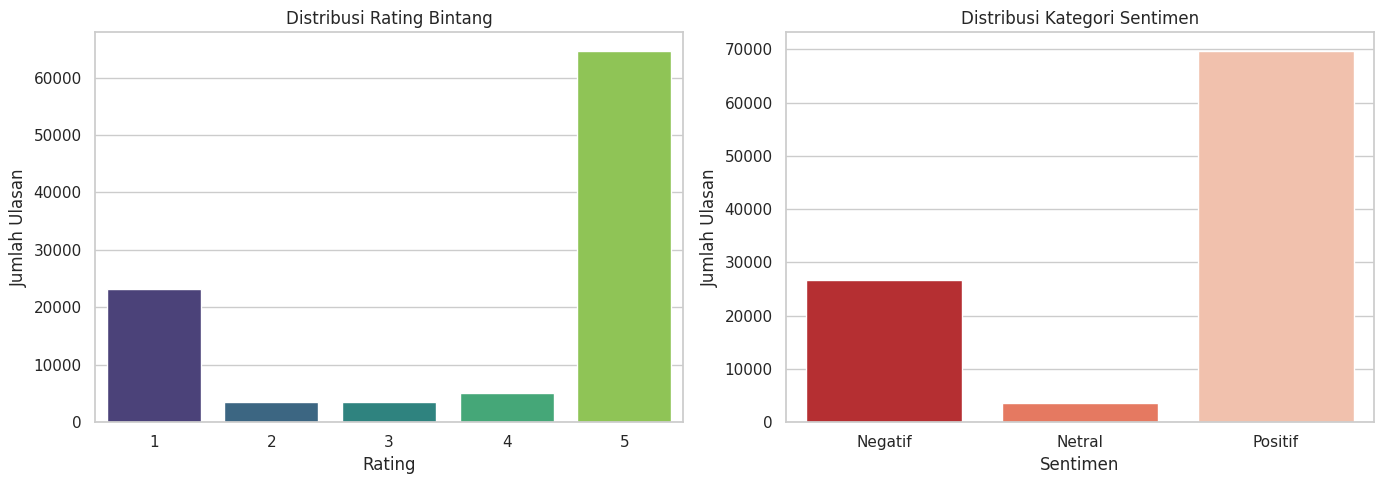


Proporsi Sentimen:
Sentimen
Positif    69.734
Negatif    26.732
Netral      3.534
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualisasi Rating
sns.countplot(data=df, x='Rating', palette='viridis', ax=axes[0])
axes[0].set_title('Distribusi Rating Bintang')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Jumlah Ulasan')

# Visualisasi Sentimen
sns.countplot(data=df, x='Sentimen', order=['Negatif', 'Netral', 'Positif'], palette='Reds_r', ax=axes[1])
axes[1].set_title('Distribusi Kategori Sentimen')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah Ulasan')

plt.tight_layout()
plt.show()

# Print proporsi
print("\nProporsi Sentimen:")
print(df['Sentimen'].value_counts(normalize=True) * 100)

### ***EDA 2 - Tren Ulasan Seiring Waktu***:

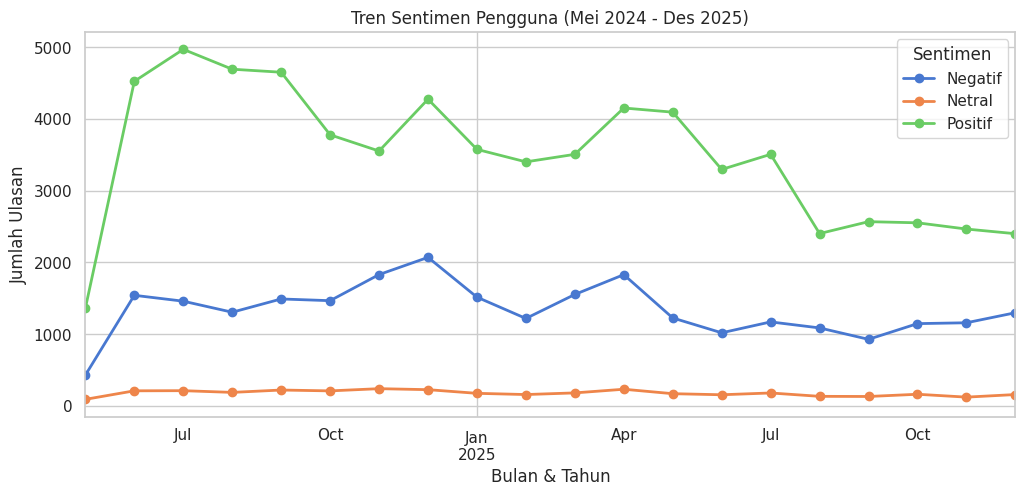

In [ ]:
plt.figure(figsize=(12, 5))
tren_sentimen = df.groupby(['Bulan_Tahun', 'Sentimen']).size().unstack(fill_value=0)

# Grafik garis
tren_sentimen.plot(kind='line', ax=plt.gca(), marker='o', linewidth=2)
plt.title('Tren Sentimen Pengguna (Mei 2024 - Des 2025)')
plt.xlabel('Bulan & Tahun')
plt.ylabel('Jumlah Ulasan')
plt.legend(title='Sentimen')
plt.show()

### ***EDA 3 - Eksplorasi Fitur "Likes" pada Keluhan***

In [ ]:
keluhan_populer = df[(df['Sentimen'] == 'Negatif') & (df['Likes'] > 0)].copy()

print(f"Ada {len(keluhan_populer)} keluhan yang disetujui (di-like) oleh pengguna lain.")

keluhan_teratas = keluhan_populer.sort_values(by='Likes', ascending=False).head(5)

print("\n--- 5 Keluhan Paling Banyak Mendapat Likes ---")
pd.set_option('display.max_colwidth', None)
display(keluhan_teratas[['Nama User', 'Rating', 'Likes', 'Versi App', 'Ulasan']])

Ada 12046 keluhan yang disetujui (di-like) oleh pengguna lain.

--- 5 Keluhan Paling Banyak Mendapat Likes ---


,Nama User,Rating,Likes,Versi App,Ulasan
41675,Pengguna Google,1,655,5.14.2,"Gak usah pasang tarif tarif hemat, soalnya para driver nya gak ada yang mau ambil orderan, dengan alasan gak sesuai dengan harga, dan bahasa mereka merendahkan costumer, karena pesen yg paket hemat, trs knp di adain paket hemat, yg salah yg punya aplikasi lah, pengen kasih promo tapi para driver nya gak mau."
40898,Pengguna Google,1,476,5.14.2,"tinggal 2menit lg driver sampe di lokasi tiba-tiba dibatalin otomatis sama aplikasinya!!! tau tau udah mencari driver yg baru, dan ini kejadian gak sekali dua kali tapi sering! map jg sering di arahin ke jalan yg sulit di lewati mobil!! alhasil banyak yg batalin! komplain via chat cuma bot doang, Kita yg mo complain gak bisa ketik sendiri masalahnya, mo complain lewat email atau tlp jg gak bisa!!! aplikasi gak niat terima komplain!!!"
69570,Pengguna Google,1,398,4.96.2,"Gojek udah ga kayak dlu. Skrg ongkirnya mahal. Ongkir gofood untuk jarak 1 -2km kayak ongkir untuk jarak 7-10km. Trus ditambah ada biaya layanan juga. Kalo pake mode hemat, prosesnya lama banget. Blm lagi nunggu dapet drivernya. Trus untuk goride kadang susah dpt drivernya. Padahal di lokasi sekitar ada banyak driver. Aplikasi juga sering error."
73605,Pengguna Google,1,381,4.94.2,Tiap order diminta parkir trs. Padahal bukan d mall. Kl d mall wajar. Tinggal ambil orderan knp hrs bayar parkir. Grab sama shopee jarang bgt minta parkir. Edukasi aja drivernya. Udh 2 kali gara2 ga mau bayar parkir malah saya d jailin driver. Orderan d lama2in. Nnt udh lama mereka cancel. Janjian kayanya tuh drivernya buat jailin konsumen. Tmn2 saya jg banyak yg kena digituin driver gara2 ga mau bayar parkir.
80507,Pengguna Google,1,332,4.93.1,"Aplikasi ini semakin berat di hp ram (1) kecil, kasihan konsumen yang masih memiliki hp android biasa seperti coolpad. Sementara mereka masih setia ingin memakai jasa gojek karena lebih nyaman. Tapi hp mereka tak mampu untuk loading disebabkan versi ini semakin berat/mb - nya semakin tinggi termasuk apk mitra driver setiap ada perubahan versi selalu terkendala (hank, lag, error) ribet Tks"


### ***Ekstraksi Topik***

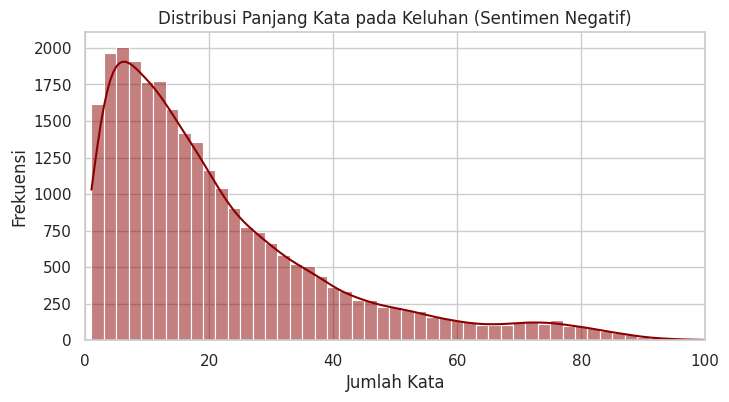


Total dataset keluhan yang siap masuk ke tahap LDA: 26732 baris.
Rata-rata panjang keluhan: 21.04 kata.


In [ ]:
df_keluhan = df[df['Sentimen'] == 'Negatif'].reset_index(drop=True)
df_keluhan['Jumlah_Kata'] = df_keluhan['Ulasan'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.histplot(df_keluhan['Jumlah_Kata'], bins=50, kde=True, color='darkred')
plt.title('Distribusi Panjang Kata pada Keluhan (Sentimen Negatif)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 100)
plt.show()

print(f"\nTotal dataset keluhan yang siap masuk ke tahap LDA: {len(df_keluhan)} baris.")
print(f"Rata-rata panjang keluhan: {df_keluhan['Jumlah_Kata'].mean():.2f} kata.")

### ***Library NLP***

In [ ]:
!pip install Sastrawi

import re
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('punkt')
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### ***Text Preprocessing***

In [ ]:
factory = StopWordRemoverFactory()
stopwords_indo = factory.get_stop_words()

# Kata gaul/umum yang tidak punya nilai sentimen
tambahan_stopword = ['yg', 'nya', 'sih', 'dong', 'gojek', 'aplikasi', 'apk', 'di', 'ke', 'dari', 'ini', 'itu', 'dan']
stopwords_indo.extend(tambahan_stopword)

# Pembersihan Teks
def bersihkan_teks(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z]+', ' ', text)
    tokens = word_tokenize(text)
    tokens_bersih = [word for word in tokens if word not in stopwords_indo and len(word) > 2]
    return ' '.join(tokens_bersih)

print("Memulai pembersihan teks 100.000 data... (Tunggu sekitar 1-2 menit)")

df['Ulasan_Bersih'] = df['Ulasan'].apply(bersihkan_teks)

print("Pembersihan teks selesai! Berikut hasilnya:")
display(df[['Ulasan', 'Ulasan_Bersih']].head())

Memulai pembersihan teks 100.000 data... (Tunggu sekitar 1-2 menit)
Pembersihan teks selesai! Berikut hasilnya:


,Ulasan,Ulasan_Bersih
0,"Mohon agar Gojek menambahkan fitur pembayaran via aplikasi Dana, supaya pilihan metode pembayaran lebih beragam, terimakasih.",mohon menambahkan fitur pembayaran via dana pilihan metode pembayaran lebih beragam terimakasih
1,aplikasi kek taik saya pesan gojek prioritas mencari driver setengah jam,kek taik pesan prioritas mencari driver setengah jam
2,oke pokonya,oke pokonya
3,good,good
4,aW see w,see


### ***Visualisasi WordCloud Keluhan***

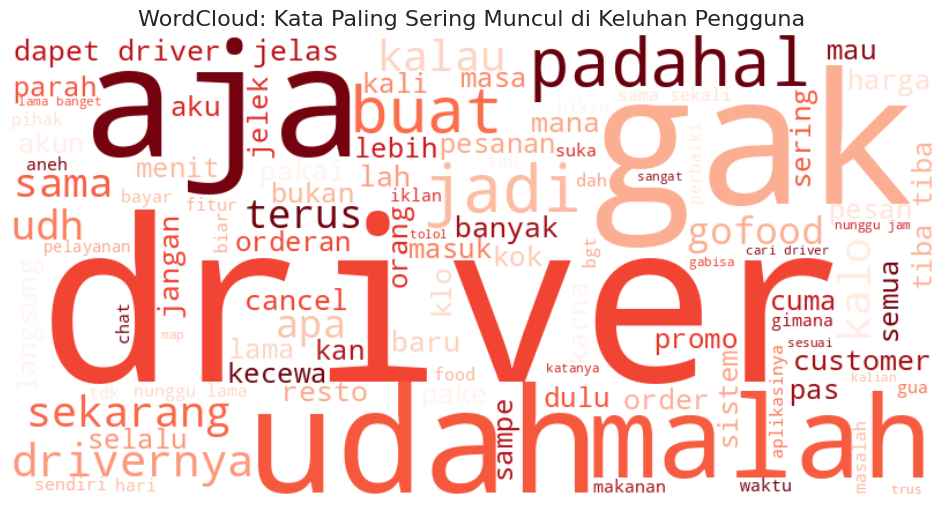

In [ ]:
# Gabung semua teks ulasan NEGATIF
teks_negatif = ' '.join(df[df['Sentimen'] == 'Negatif']['Ulasan_Bersih'])

# WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='Reds', max_words=100).generate(teks_negatif)

# Menampilkan WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Kata Paling Sering Muncul di Keluhan Pengguna', fontsize=16)
plt.show()

### ***Ekstraksi Fitur (TF-IDF) & Pembagian Data (Train-Test Split)***

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['Ulasan_Bersih']
y = df['Sentimen']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Jumlah data untuk melatih model: {X_train_tfidf.shape[0]} ulasan")
print(f"Jumlah data untuk menguji akurasi model: {X_test_tfidf.shape[0]} ulasan")

Jumlah data untuk melatih model: 80000 ulasan
Jumlah data untuk menguji akurasi model: 20000 ulasan


### ***Model Baseline SVM & Evaluasi Akurasi***

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

print("Memulai pelatihan model SVM Baseline...")

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

y_pred = svm_model.predict(X_test_tfidf)

akurasi = accuracy_score(y_test, y_pred)
print(f"\n--- AKURASI MODEL SVM SEMENTARA: {akurasi * 100:.2f}% ---\n")

print("--- Detail Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))

Memulai pelatihan model SVM Baseline...

--- AKURASI MODEL SVM SEMENTARA: 89.33% ---

--- Detail Laporan Klasifikasi ---
              precision    recall  f1-score   support

     Negatif       0.81      0.85      0.83      5437
      Netral       0.15      0.01      0.01       734
     Positif       0.93      0.96      0.94     13829

    accuracy                           0.89     20000
   macro avg       0.63      0.61      0.60     20000
weighted avg       0.87      0.89      0.88     20000



### ***Confusion Matrix***

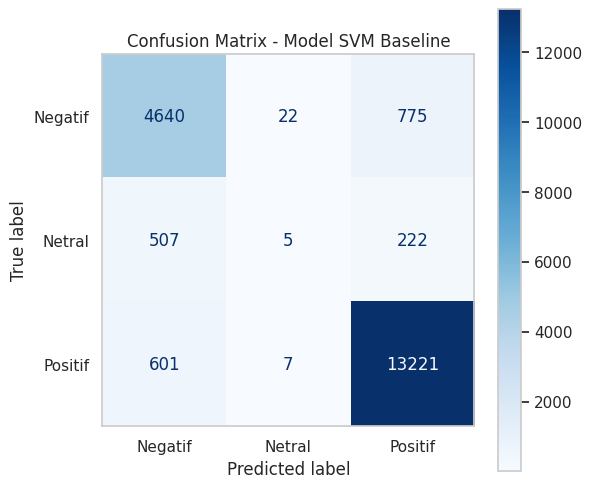

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Menghitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)

# Visualisasi Matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')

plt.title('Confusion Matrix - Model SVM Baseline')
plt.grid(False)
plt.show()

### ***Optimasi SVM***

In [ ]:
from sklearn.svm import LinearSVC

print("Melatih Model SVM Final dengan Class Weight Balanced...")

# Tuning
svm_final = LinearSVC(class_weight='balanced', C=0.5, random_state=42)

# Model Final
svm_final.fit(X_train_tfidf, y_train)

# Prediksi dan Evaluasi Teks
y_pred_final = svm_final.predict(X_test_tfidf)
akurasi_final = accuracy_score(y_test, y_pred_final)

print(f"\n AKURASI MODEL SVM FINAL: {akurasi_final * 100:.2f}% ---\n")
print("--- Laporan Klasifikasi Final ---")
print(classification_report(y_test, y_pred_final))

Melatih Model SVM Final dengan Class Weight Balanced...

 AKURASI MODEL SVM FINAL: 87.99% ---

--- Laporan Klasifikasi Final ---
              precision    recall  f1-score   support

     Negatif       0.81      0.83      0.82      5437
      Netral       0.17      0.22      0.19       734
     Positif       0.96      0.93      0.94     13829

    accuracy                           0.88     20000
   macro avg       0.65      0.66      0.65     20000
weighted avg       0.89      0.88      0.88     20000



### ***Ekstraksi Topik / LDA***

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

print("Menyiapkan Data Khusus Sentimen Negatif untuk LDA...")

# Filter hanya ulasan bersentimen Negatif
df_negatif = df[df['Sentimen'] == 'Negatif'].copy()

df_negatif = df_negatif.dropna(subset=['Ulasan_Bersih'])
df_negatif = df_negatif[df_negatif['Ulasan_Bersih'] != '']

# Ekstraksi Fitur (CountVectorizer)
tf_vectorizer = CountVectorizer(max_features=2000, max_df=0.9, min_df=5)
tf_negatif = tf_vectorizer.fit_transform(df_negatif['Ulasan_Bersih'])

print(f"Data keluhan siap diproses LDA: {tf_negatif.shape[0]} ulasan, {tf_negatif.shape[1]} kata unik.")

Menyiapkan Data Khusus Sentimen Negatif untuk LDA...
Data keluhan siap diproses LDA: 26639 ulasan, 2000 kata unik.


### ***Pemodelan Topik LDA***

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

jumlah_topik = 3

print(f"Memulai proses pemodelan ke dalam {jumlah_topik} klaster topik keluhan...")
print("Proses ini memakan waktu sekitar 30 detik - 1 menit...\n")

# Inisialisasi Model LDA
lda_model = LatentDirichletAllocation(n_components=jumlah_topik,
                                      random_state=42,
                                      max_iter=10,
                                      learning_method='online')

# Melatih Model LDA
lda_model.fit(tf_negatif)

print("Model LDA Berhasil Dilatih!")

Memulai proses pemodelan ke dalam 3 klaster topik keluhan...
Proses ini memakan waktu sekitar 30 detik - 1 menit...

Model LDA Berhasil Dilatih!


### ***Menampilkan Kata Kunci Per Topik***

In [ ]:
def tampilkan_topik(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"--- Topik {topic_idx + 1} ---")
        # Mengambil indeks kata dengan probabilitas tertinggi
        top_features_ind = topic.argsort()[:-no_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        print(", ".join(top_features))
        print("")

# Menampilkan 10 kata paling relevan untuk masing-masing topik
fitur_kata = tf_vectorizer.get_feature_names_out()
print("HASIL EKSTRAKSI TOPIK KELUHAN:\n")
tampilkan_topik(lda_model, fitur_kata, 10)

HASIL EKSTRAKSI TOPIK KELUHAN:

--- Topik 1 ---
driver, lama, gofood, jam, nunggu, udah, cancel, makanan, susah, banget

--- Topik 2 ---
gopay, gak, masuk, padahal, mau, saldo, aja, akun, udah, pake

--- Topik 3 ---
driver, banyak, mahal, gocar, mau, sama, jauh, lebih, gak, drivernya



### ***Visualisasi pyLDAvis***

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Membangun Dashboard Visualisasi Topik Keluhan...


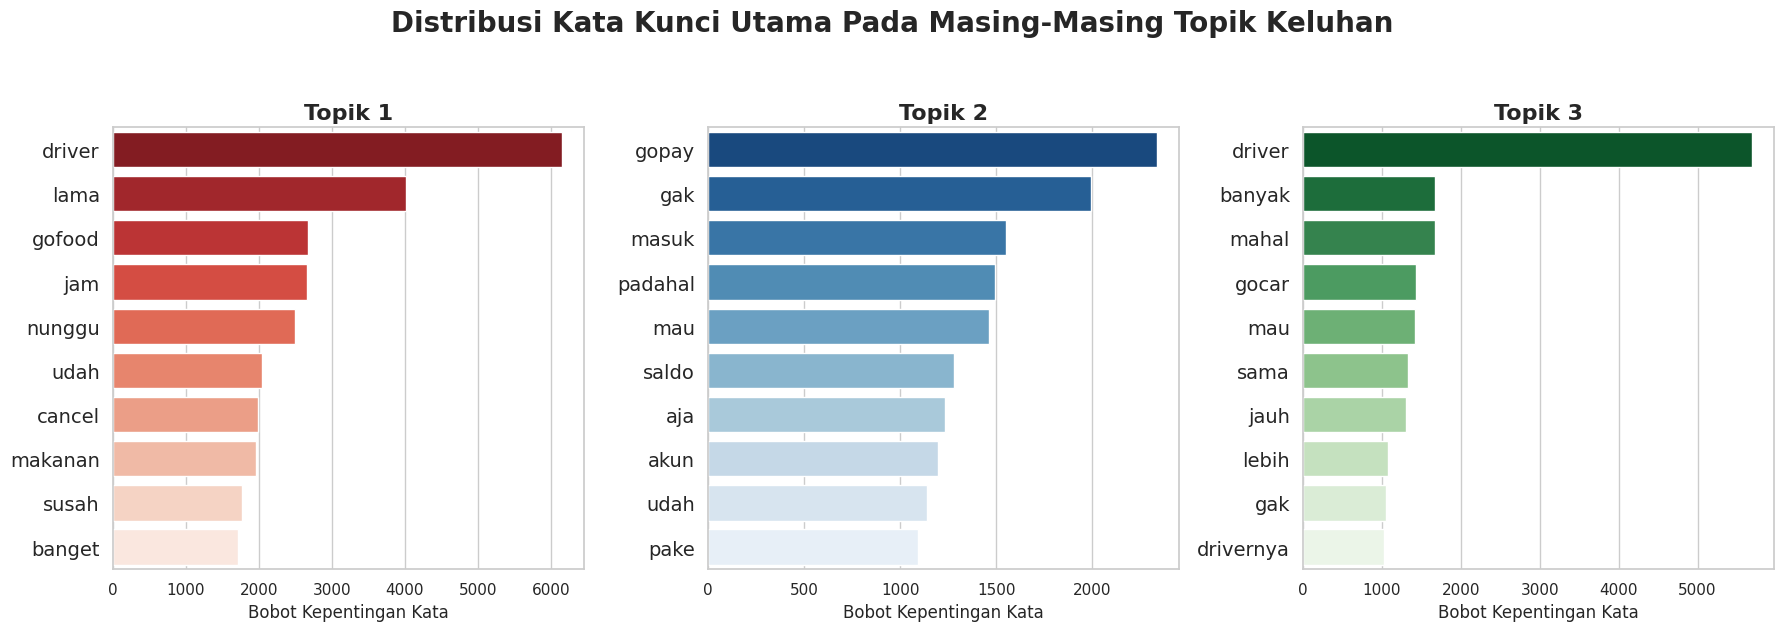

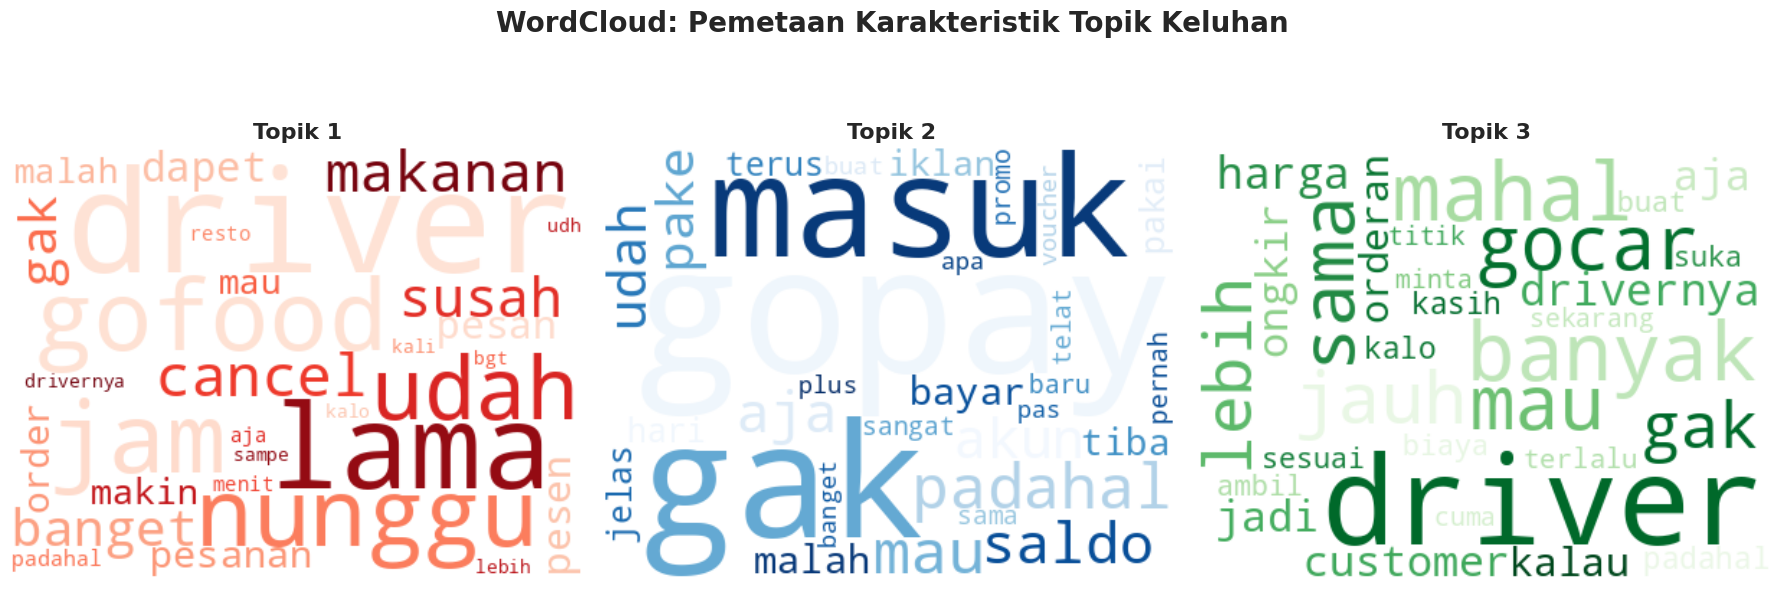

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")

print("Membangun Dashboard Visualisasi Topik Keluhan...")

fitur_kata = tf_vectorizer.get_feature_names_out()
jumlah_kata_top = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)
fig.suptitle('Distribusi Kata Kunci Utama Pada Masing-Masing Topik Keluhan', fontsize=20, fontweight='bold', y=1.05)

warna_topik = ['Reds_r', 'Blues_r', 'Greens_r']

for topic_idx, topic in enumerate(lda_model.components_):
    top_features_ind = topic.argsort()[:-jumlah_kata_top - 1:-1]
    top_features = [fitur_kata[i] for i in top_features_ind]
    bobot = topic[top_features_ind]

    ax = axes[topic_idx]
    sns.barplot(x=bobot, y=top_features, ax=ax, palette=warna_topik[topic_idx])
    ax.set_title(f'Topik {topic_idx + 1}', fontdict={'fontsize': 16, 'fontweight': 'bold'})
    ax.set_xlabel('Bobot Kepentingan Kata', fontsize=12)
    ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('WordCloud: Pemetaan Karakteristik Topik Keluhan', fontsize=20, fontweight='bold', y=1.05)

tema_warna_wc = ['Reds', 'Blues', 'Greens']

for topic_idx, topic in enumerate(lda_model.components_):
    top_features_ind = topic.argsort()[:-30 - 1:-1]
    dict_kata = {fitur_kata[i]: topic[i] for i in top_features_ind}

    wc = WordCloud(width=400, height=300, background_color='white', colormap=tema_warna_wc[topic_idx])
    wc.generate_from_frequencies(dict_kata)

    ax = axes[topic_idx]
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topik {topic_idx + 1}', fontdict={'fontsize': 16, 'fontweight': 'bold'})
    ax.axis('off')

plt.tight_layout()
plt.show()

### ***Final Confusion Matrix***

--- Evaluasi Akhir: Visualisasi Confusion Matrix Model SVM Final ---


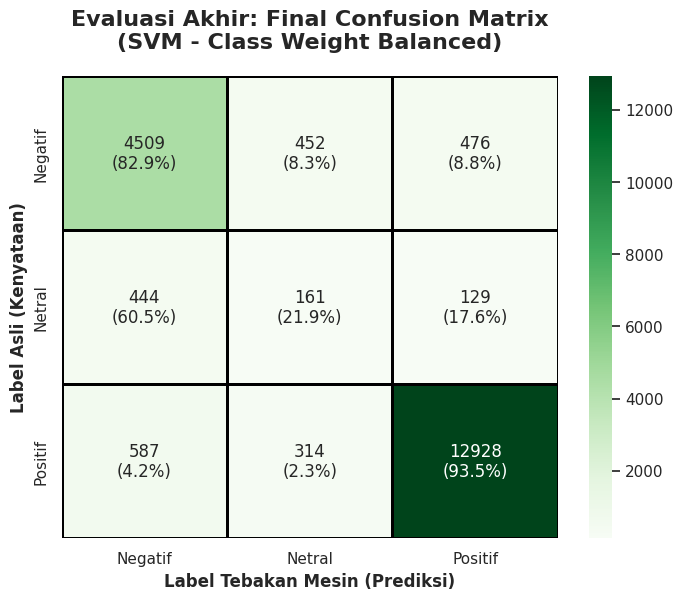


ANALISIS DETAIL PERFORMA MODEL SVM FINAL
Penjelasan Metrik Evaluasi:
- Akurasi Keseluruhan sedikit menurun dibanding baseline (hal yang wajar pada Imbalanced Data).
- Namun, perhatikan nilai RECALL pada sentimen 'Negatif' di bawah ini.
- Model kini lebih peka dan adil dalam menjaring ulasan-ulasan yang berisi keluhan,
  sehingga data yang disuapkan ke algoritma LDA menjadi lebih berkualitas dan relevan.

--- Laporan Klasifikasi Lengkap ---
              precision    recall  f1-score   support

     Negatif       0.81      0.83      0.82      5437
      Netral       0.17      0.22      0.19       734
     Positif       0.96      0.93      0.94     13829

    accuracy                           0.88     20000
   macro avg       0.65      0.66      0.65     20000
weighted avg       0.89      0.88      0.88     20000



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("--- Evaluasi Akhir: Visualisasi Confusion Matrix Model SVM Final ---")

# Confusion Matrix Final
cm_final = confusion_matrix(y_test, y_pred_final, labels=svm_final.classes_)

# Visualisasi Heatmap
plt.figure(figsize=(8, 6))

cm_persentase = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
anotasi = [f"{nilai}\n({persen:.1%})" for nilai, persen in zip(cm_final.flatten(), cm_persentase.flatten())]
anotasi = np.asarray(anotasi).reshape(cm_final.shape)

sns.heatmap(cm_final, annot=anotasi, fmt='', cmap='Greens',
            xticklabels=svm_final.classes_,
            yticklabels=svm_final.classes_,
            linewidths=1, linecolor='black')

plt.title('Evaluasi Akhir: Final Confusion Matrix\n(SVM - Class Weight Balanced)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Label Asli (Kenyataan)', fontsize=12, fontweight='bold')
plt.xlabel('Label Tebakan Mesin (Prediksi)', fontsize=12, fontweight='bold')
plt.show()

print("\n" + "="*80)
print("ANALISIS DETAIL PERFORMA MODEL SVM FINAL")
print("="*80)
print("Penjelasan Metrik Evaluasi:")
print("- Akurasi Keseluruhan sedikit menurun dibanding baseline (hal yang wajar pada Imbalanced Data).")
print("- Namun, perhatikan nilai RECALL pada sentimen 'Negatif' di bawah ini.")
print("- Model kini lebih peka dan adil dalam menjaring ulasan-ulasan yang berisi keluhan,\n  sehingga data yang disuapkan ke algoritma LDA menjadi lebih berkualitas dan relevan.\n")

print("--- Laporan Klasifikasi Lengkap ---")
print(classification_report(y_test, y_pred_final))